### Investigate the variant results from Bcalm for each cell-type and identify if you find significant effects
- 0. Start FIMO or HOMER on the sequences from the design file
- 1. generate a volcano plot of the significant variants for each of the three cell-types and each of the variant groups 
- 2. Investigate if there is a clear difference between the ratio of significant variants in the different variant groups
- 3. generate a upset plot of the significant variants within each of the cell-types


In [1]:
import pandas as pd

In [2]:
# variant bcalm data:
huvec_variant_path = "/data/cephfs-2/unmirrored/projects/periodontitis-mpra/pd-MPRA-analysis-code/results/variant_bcalm_results/HUVEC_variant_bcalm_bbmap_normalized_counts_202506.tsv"
ihgf_variant_path = "/data/cephfs-2/unmirrored/projects/periodontitis-mpra/pd-MPRA-analysis-code/results/variant_bcalm_results/IHGF_variant_bcalm_bbmap_normalized_counts_202506.tsv"
okg4_variant_path = "/data/cephfs-2/unmirrored/projects/periodontitis-mpra/pd-MPRA-analysis-code/results/variant_bcalm_results/OKG4_variant_bcalm_bbmap_normalized_counts_202506.tsv"

huvec_variant_df = pd.read_csv(huvec_variant_path, sep="\t")
ihgf_variant_df = pd.read_csv(ihgf_variant_path, sep="\t")
okg4_variant_df = pd.read_csv(okg4_variant_path, sep="\t")

In [3]:
additional_info_path = "/data/cephfs-2/unmirrored/projects/periodontitis-mpra/design_file/240106_complete_PD_MPRA_design_agilent_format_code_translation.csv"
additional_info_table_df = pd.read_csv(additional_info_path, sep=";")
print(additional_info_table_df.columns)
additional_info_table_df

Index(['SequenceName', 'SequenceName_long', 'Sequence', 'Replication'], dtype='object')


,SequenceName,SequenceName_long,Sequence,Replication
0,CB_404305_000000,>C_ELS_positive:hg38_(.):chr1:153536729-153536...,AGGACCGGATCAACTTGCAAGGATGCAGAGGAAGTTAAGAGGGAAA...,1
1,CB_404305_000001,>C_ELS_positive:hg38_(.):chr1:153991341-153991...,AGGACCGGATCAACTGGAAAATATTTTCCCTGATACTCTTAAAATT...,1
2,CB_404305_000002,>C_ELS_positive:hg38_(.):chr1:44774679-4477487...,AGGACCGGATCAACTTGTGCGTCACCATGCTCAACTAAATTTTGTA...,1
3,CB_404305_000003,>C_ELS_positive:hg38_(.):chr10:17232397-172325...,AGGACCGGATCAACTGATTTGGAATGCTGAGCTTTTTAAATGGAAA...,1
4,CB_404305_000004,>C_ELS_positive:hg38_(.):chr10:78035107-780353...,AGGACCGGATCAACTACACATAACCTAGTGAAGTAAGTTGTACAGA...,1
...,...,...,...,...
2539,CB_404305_002539,LINC01192_rs9865266_alt_G,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,1
2540,CB_404305_002540,LINC01192_rs9865266_ref_A,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,1
2541,CB_404305_002541,LINC01192_rs996784_alt_A,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,1
2542,CB_404305_002542,LINC01192_rs996784_alt_G,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,1


In [4]:
# remove > if present from the SequeneName_long column
additional_info_table_df["SequenceName_long"] = additional_info_table_df["SequenceName_long"].str.replace(">", "", regex=False)
# generate label column
additional_info_table_df["label"] = additional_info_table_df["SequenceName_long"].str.split(":").str[0]
additional_info_table_df = additional_info_table_df[['SequenceName', 'SequenceName_long', 'Sequence', 'label']].copy()
# additional_info_table_df['label'].value_counts().reset_index(name='count')['count'].sum()
# 2544

In [5]:
additional_info_table_df.columns

Index(['SequenceName', 'SequenceName_long', 'Sequence', 'label'], dtype='object')

In [6]:
additional_info_table_df['label'].value_counts()

label
V_SNV_ALT                        907
V_SNV_REF                        530
C_ELS_positive                   136
V_INDEL_ALT                      108
C_SLEA_negative                   87
                                ... 
LINC01192_rs2307722_alt_TATAT      1
LINC01192_rs2307722_ref_TAT        1
LINC01192_rs2363852_alt_A          1
LINC01192_rs2363852_ref_T          1
LINC02292_rs2144815_ref_T          1
Name: count, Length: 552, dtype: int64

In [7]:
additional_info_table_df

,SequenceName,SequenceName_long,Sequence,label
0,CB_404305_000000,C_ELS_positive:hg38_(.):chr1:153536729-1535369...,AGGACCGGATCAACTTGCAAGGATGCAGAGGAAGTTAAGAGGGAAA...,C_ELS_positive
1,CB_404305_000001,C_ELS_positive:hg38_(.):chr1:153991341-1539915...,AGGACCGGATCAACTGGAAAATATTTTCCCTGATACTCTTAAAATT...,C_ELS_positive
2,CB_404305_000002,C_ELS_positive:hg38_(.):chr1:44774679-44774879...,AGGACCGGATCAACTTGTGCGTCACCATGCTCAACTAAATTTTGTA...,C_ELS_positive
3,CB_404305_000003,C_ELS_positive:hg38_(.):chr10:17232397-1723259...,AGGACCGGATCAACTGATTTGGAATGCTGAGCTTTTTAAATGGAAA...,C_ELS_positive
4,CB_404305_000004,C_ELS_positive:hg38_(.):chr10:78035107-7803530...,AGGACCGGATCAACTACACATAACCTAGTGAAGTAAGTTGTACAGA...,C_ELS_positive
...,...,...,...,...
2539,CB_404305_002539,LINC01192_rs9865266_alt_G,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,LINC01192_rs9865266_alt_G
2540,CB_404305_002540,LINC01192_rs9865266_ref_A,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,LINC01192_rs9865266_ref_A
2541,CB_404305_002541,LINC01192_rs996784_alt_A,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,LINC01192_rs996784_alt_A
2542,CB_404305_002542,LINC01192_rs996784_alt_G,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,LINC01192_rs996784_alt_G


In [8]:
variant_map_path =  "/data/cephfs-2/unmirrored/projects/periodontitis-mpra/design_file/PERO_toy_design_variant_map.tsv.gz"
variant_map_df = pd.read_csv(variant_map_path, sep="\t", compression="gzip")
print(variant_map_df.columns)
variant_map_df

Index(['ID', 'ALT', 'REF'], dtype='object')


,ID,ALT,REF
0,CB_404305_000568,CB_404305_000568,CB_404305_001475
1,CB_404305_000569,CB_404305_000569,CB_404305_001476
2,CB_404305_000570,CB_404305_000570,CB_404305_001476
3,CB_404305_000571,CB_404305_000571,CB_404305_001477
4,CB_404305_002193,CB_404305_002193,CB_404305_002194
...,...,...,...
1215,CB_404305_001470,CB_404305_001470,CB_404305_002002
1216,CB_404305_001471,CB_404305_001471,CB_404305_002003
1217,CB_404305_001472,CB_404305_001472,CB_404305_002003
1218,CB_404305_001473,CB_404305_001473,CB_404305_002004


### Variant centric dataframe

In [10]:
print("Generating variant-centric matrix...")

# Select and rename columns for HUVEC data
huvec_matrix_df = huvec_variant_df[['variant_id', 'logFC', 'adj.P.Val']].copy()
huvec_matrix_df.rename(columns={
    'logFC': 'logFC_HUVEC',
    'adj.P.Val': 'adj_pvalue_HUVEC'
}, inplace=True)

# Select and rename columns for IHGF data
ihgf_matrix_df = ihgf_variant_df[['variant_id', 'logFC', 'adj.P.Val']].copy()
ihgf_matrix_df.rename(columns={
    'logFC': 'logFC_IHGF',
    'adj.P.Val': 'adj_pvalue_IHGF'
}, inplace=True)

# Select and rename columns for OKG4 data
okg4_matrix_df = okg4_variant_df[['variant_id', 'logFC', 'adj.P.Val']].copy()
okg4_matrix_df.rename(columns={
    'logFC': 'logFC_OKG4',
    'adj.P.Val': 'adj_pvalue_OKG4'
}, inplace=True)

# Merge the dataframes starting with HUVEC, using outer joins to keep all variants
variant_centric_matrix = pd.merge(huvec_matrix_df, ihgf_matrix_df, on='variant_id', how='outer')
variant_centric_matrix = pd.merge(variant_centric_matrix, okg4_matrix_df, on='variant_id', how='outer')

print("\nVariant-Centric Matrix created successfully.")
print(f"Total number of unique variants in the matrix: {len(variant_centric_matrix)}")
print("Head of the Variant-Centric Matrix:")
print(variant_centric_matrix.head())

# Display descriptive statistics for a quick overview
print("\nDescriptive statistics for logFC and adj_pvalue across cell types:")
print(variant_centric_matrix[['logFC_HUVEC', 'logFC_IHGF', 'logFC_OKG4',
                              'adj_pvalue_HUVEC', 'adj_pvalue_IHGF', 'adj_pvalue_OKG4']].describe())

# Check for NaN values (variants present in some cell types but not others)
print("\nNumber of NaN values per column (missing data for that cell type/metric):")
print(variant_centric_matrix.isnull().sum())

Generating variant-centric matrix...

Variant-Centric Matrix created successfully.
Total number of unique variants in the matrix: 1158
Head of the Variant-Centric Matrix:
         variant_id  logFC_HUVEC  adj_pvalue_HUVEC  logFC_IHGF  \
0  CB_404305_000413     0.095099          0.401457   -0.031695   
1  CB_404305_000414     0.073323          0.546036   -0.079418   
2  CB_404305_000415    -0.108604          0.342878   -0.122103   
3  CB_404305_000416     0.047242          0.722612   -0.051763   
4  CB_404305_000418     0.028593          0.831222    0.060408   

   adj_pvalue_IHGF  logFC_OKG4  adj_pvalue_OKG4  
0         0.701917    0.019382         0.879174  
1         0.261043   -0.004801         0.973792  
2         0.030997   -0.123463         0.147734  
3         0.488595    0.045334         0.670414  
4         0.379118    0.059736         0.539710  

Descriptive statistics for logFC and adj_pvalue across cell types:
       logFC_HUVEC   logFC_IHGF   logFC_OKG4  adj_pvalue_HUVEC  

In [11]:
variant_centric_matrix

,variant_id,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,logFC_OKG4,adj_pvalue_OKG4
0,CB_404305_000413,0.095099,0.401457,-0.031695,0.701917,0.019382,0.879174
1,CB_404305_000414,0.073323,0.546036,-0.079418,0.261043,-0.004801,0.973792
2,CB_404305_000415,-0.108604,0.342878,-0.122103,0.030997,-0.123463,0.147734
3,CB_404305_000416,0.047242,0.722612,-0.051763,0.488595,0.045334,0.670414
4,CB_404305_000418,0.028593,0.831222,0.060408,0.379118,0.059736,0.539710
...,...,...,...,...,...,...,...
1153,CB_404305_002535,0.007600,0.970469,-0.006009,0.969653,0.016015,0.937603
1154,CB_404305_002537,0.097124,0.614316,-0.023912,0.866416,0.068919,0.724334
1155,CB_404305_002539,-0.074349,0.564789,0.028266,0.769326,-0.045795,0.681317
1156,CB_404305_002541,-0.035551,0.807710,-0.003111,0.980251,-0.014034,0.926668


In [100]:
# Step 1: Merge with variant_map_df to get ALT and REF
# 'ID' in variant_map_df corresponds to 'variant_id' in our matrix
enriched_matrix = pd.merge(variant_centric_matrix, variant_map_df, left_on='variant_id', right_on='ID', how='left')
enriched_matrix.drop(columns=['ID'], inplace=True) # Drop the redundant ID column from variant_map

print(f"Matrix after merging with variant_map: {enriched_matrix.shape[0]} rows, {enriched_matrix.shape[1]} columns.")
# print(enriched_matrix.head()) # Uncomment to inspect intermediate result

# Step 2: Merge with additional_info_table_df for ALT sequences
# Rename columns in additional_info_table_df to be specific to ALT before merging
alt_info_df = additional_info_table_df.rename(columns={
    'SequenceName': 'ALT', # This is the key to merge on
    'SequenceName_long': 'SequenceName_long_ALT',
    'Sequence': 'Sequence_ALT',
    'label': 'label_ALT' # New label column for ALT
})
enriched_matrix = pd.merge(enriched_matrix, alt_info_df, on='ALT', how='left')

print(f"Matrix after merging ALT info: {enriched_matrix.shape[0]} rows, {enriched_matrix.shape[1]} columns.")
# print(enriched_matrix.head()) # Uncomment to inspect intermediate result

# Step 3: Merge with additional_info_table_df for REF sequences
# Rename columns in additional_info_table_df to be specific to REF before merging
ref_info_df = additional_info_table_df.rename(columns={
    'SequenceName': 'REF', # This is the key to merge on
    'SequenceName_long': 'SequenceName_long_REF',
    'Sequence': 'Sequence_REF',
    'label': 'label_REF' # New label column for REF
})
enriched_matrix = pd.merge(enriched_matrix, ref_info_df, on='REF', how='left')

print(f"Matrix after merging REF info: {enriched_matrix.shape[0]} rows, {enriched_matrix.shape[1]} columns.")

# --- Step 4: Add the variant_group column using the new label_ALT and label_REF ---
# Re-using the classification logic from the previous turn
def classify_variant_group(row):
    label_alt = str(row['label_ALT']).lower() if pd.notna(row['label_ALT']) else ''
    label_ref = str(row['label_REF']).lower() if pd.notna(row['label_REF']) else ''

    if 'snv' in label_alt or 'snv' in label_ref:
        return 'SNV'
    elif 'linc' in label_alt or 'linc' in label_ref:
        return 'LINC'
    elif 'indel' in label_alt or 'indel' in label_ref:
        return 'INDEL'
    else:
        return 'Other' # For variants that don't match any of the defined groups

print("\nClassifying variants into groups (SNV, LINC, INDEL, Other) within the enriched matrix...")
enriched_matrix['variant_group'] = enriched_matrix.apply(classify_variant_group, axis=1)

print("\nEnriched Variant-Centric Matrix created successfully!")
print("Head of the Enriched Variant-Centric Matrix:")
print(enriched_matrix.head())

print("\nColumns in the Enriched Variant-Centric Matrix:")
print(enriched_matrix.columns.tolist())

print("\nCheck for missing values in newly added columns (NaNs indicate missing metadata):")
# Select columns that are expected to have come from the merge for a quick check
metadata_columns_to_check = [
    'ALT', 'REF', 'SequenceName_long_ALT', 'Sequence_ALT', 'label_ALT',
    'SequenceName_long_REF', 'Sequence_REF', 'label_REF', 'variant_group'
]
print(enriched_matrix[metadata_columns_to_check].isnull().sum())

Matrix after merging with variant_map: 1158 rows, 9 columns.
Matrix after merging ALT info: 1158 rows, 12 columns.
Matrix after merging REF info: 1158 rows, 15 columns.

Classifying variants into groups (SNV, LINC, INDEL, Other) within the enriched matrix...

Enriched Variant-Centric Matrix created successfully!
Head of the Enriched Variant-Centric Matrix:
         variant_id  logFC_HUVEC  adj_pvalue_HUVEC  logFC_IHGF  \
0  CB_404305_000413     0.095099          0.401457   -0.031695   
1  CB_404305_000414     0.073323          0.546036   -0.079418   
2  CB_404305_000415    -0.108604          0.342878   -0.122103   
3  CB_404305_000416     0.047242          0.722612   -0.051763   
4  CB_404305_000418     0.028593          0.831222    0.060408   

   adj_pvalue_IHGF  logFC_OKG4  adj_pvalue_OKG4               ALT  \
0         0.701917    0.019382         0.879174  CB_404305_000413   
1         0.261043   -0.004801         0.973792  CB_404305_000414   
2         0.030997   -0.123463       

In [101]:
enriched_matrix

,variant_id,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,logFC_OKG4,adj_pvalue_OKG4,ALT,REF,SequenceName_long_ALT,Sequence_ALT,label_ALT,SequenceName_long_REF,Sequence_REF,label_REF,variant_group
0,CB_404305_000413,0.095099,0.401457,-0.031695,0.701917,0.019382,0.879174,CB_404305_000413,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783346-78783...,AGGACCGGATCAACTTGCAGCCTCTGCCTCCCGGGTTCAAGCGATT...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF,INDEL
1,CB_404305_000414,0.073323,0.546036,-0.079418,0.261043,-0.004801,0.973792,CB_404305_000414,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,AGGACCGGATCAACTAGCCTCTGCCTCCCGGGTTCAAGCGATTCTC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF,INDEL
2,CB_404305_000415,-0.108604,0.342878,-0.122103,0.030997,-0.123463,0.147734,CB_404305_000415,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,AGGACCGGATCAACTAGCCTCTGCCTCCCGGGTTCAAGCGATTCTC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF,INDEL
3,CB_404305_000416,0.047242,0.722612,-0.051763,0.488595,0.045334,0.670414,CB_404305_000416,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF,INDEL
4,CB_404305_000418,0.028593,0.831222,0.060408,0.379118,0.059736,0.539710,CB_404305_000418,CB_404305_000523,V_INDEL_ALT:hg38_positive:chr15:78793253-78793...,AGGACCGGATCAACTAAGTTTGGGGAATGCTGCCTGCCTATTCTGT...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78793254-78793...,AGGACCGGATCAACTAGTTTGGGGAATGCTGCCTGCCTATTCTGTT...,V_INDEL_REF,INDEL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,CB_404305_002535,0.007600,0.970469,-0.006009,0.969653,0.016015,0.937603,CB_404305_002535,CB_404305_002536,LINC01192_rs9855879_alt_A,AGGACCGGATCAACTTTGGCTCACTTATTTACCTCCTTAGTTTTGC...,LINC01192_rs9855879_alt_A,LINC01192_rs9855879_ref_C,AGGACCGGATCAACTTTGGCTCACTTATTTACCTCCTTAGTTTTGC...,LINC01192_rs9855879_ref_C,LINC
1154,CB_404305_002537,0.097124,0.614316,-0.023912,0.866416,0.068919,0.724334,CB_404305_002537,CB_404305_002538,LINC01192_rs9857851_alt_A,AGGACCGGATCAACTTTTTAATAAGTCTTTATTTTAATTTTTGAAT...,LINC01192_rs9857851_alt_A,LINC01192_rs9857851_ref_C,AGGACCGGATCAACTTTTTAATAAGTCTTTATTTTAATTTTTGAAT...,LINC01192_rs9857851_ref_C,LINC
1155,CB_404305_002539,-0.074349,0.564789,0.028266,0.769326,-0.045795,0.681317,CB_404305_002539,CB_404305_002540,LINC01192_rs9865266_alt_G,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,LINC01192_rs9865266_alt_G,LINC01192_rs9865266_ref_A,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,LINC01192_rs9865266_ref_A,LINC
1156,CB_404305_002541,-0.035551,0.807710,-0.003111,0.980251,-0.014034,0.926668,CB_404305_002541,CB_404305_002543,LINC01192_rs996784_alt_A,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,LINC01192_rs996784_alt_A,LINC01192_rs996784_ref_T,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,LINC01192_rs996784_ref_T,LINC


In [102]:
enriched_matrix['variant_group'].value_counts()

variant_group
SNV      787
LINC     294
INDEL     77
Name: count, dtype: int64

### Plot volcano plots for each variant group

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import math
def plot_volcano(MPRAlm_table, title, logFC_col, adj_p_val_col, significants_niveau=0.1, ylim_max=11, ylim_min=-0.025, xlim_min=-1, xlim_max=1, sig_dot_size=8):
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table[logFC_col] > 0) & (MPRAlm_table[adj_p_val_col] < significants_niveau), 'positive', 'neutral')
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table[logFC_col] < 0) & (MPRAlm_table[adj_p_val_col] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

    significant_MPRAlm_table = MPRAlm_table[MPRAlm_table[adj_p_val_col] < significants_niveau]
    up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
    down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=MPRAlm_table[logFC_col],y=MPRAlm_table[adj_p_val_col].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down[logFC_col],y=down[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up[logFC_col],y=up[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([xlim_min,xlim_max])
    ax.set_ylim([ylim_min,ylim_max])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(-math.log10(significants_niveau),color="grey",linestyle="--")
    plt.title(title)
    plt.legend()
    plt.show()

In [104]:
huvec_variant_df.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'mpralm_true', 'cell_type'],
      dtype='object')

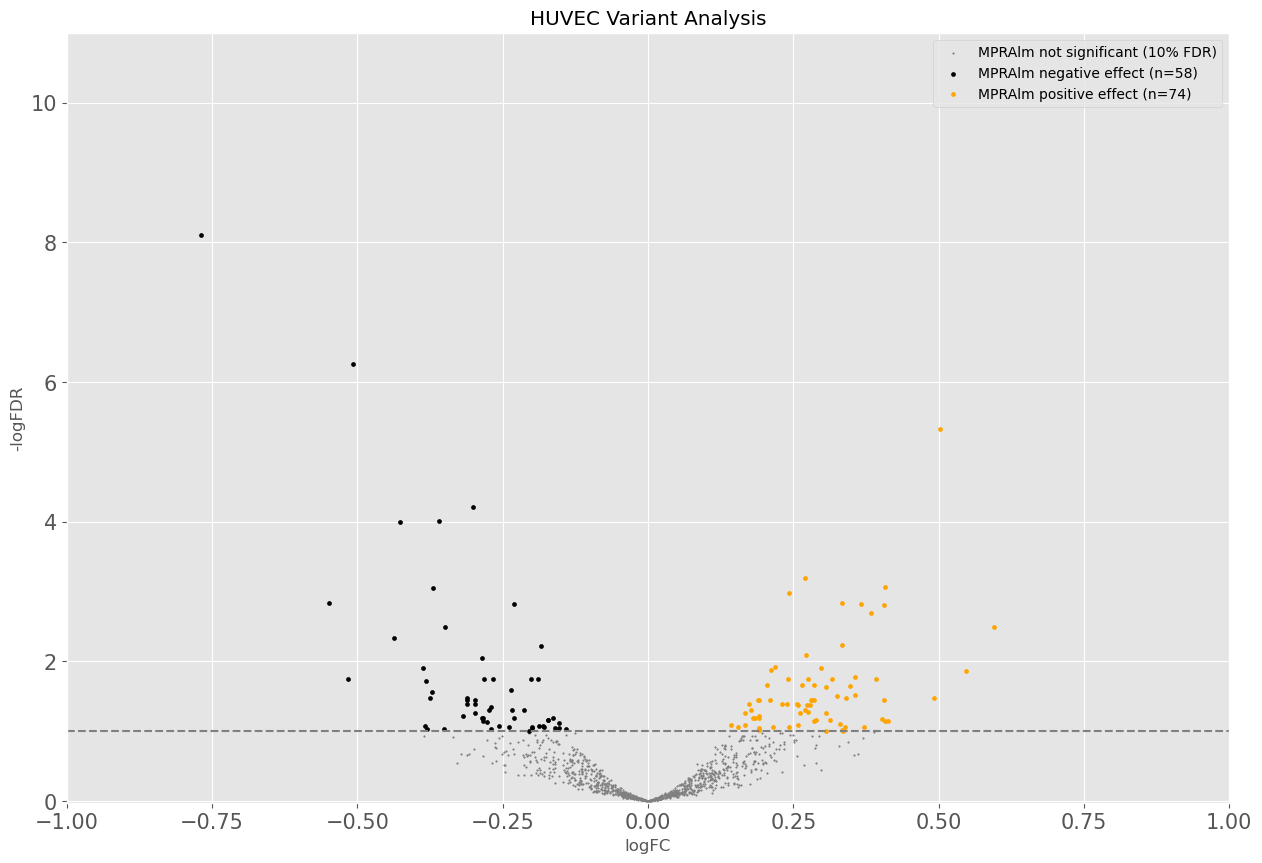

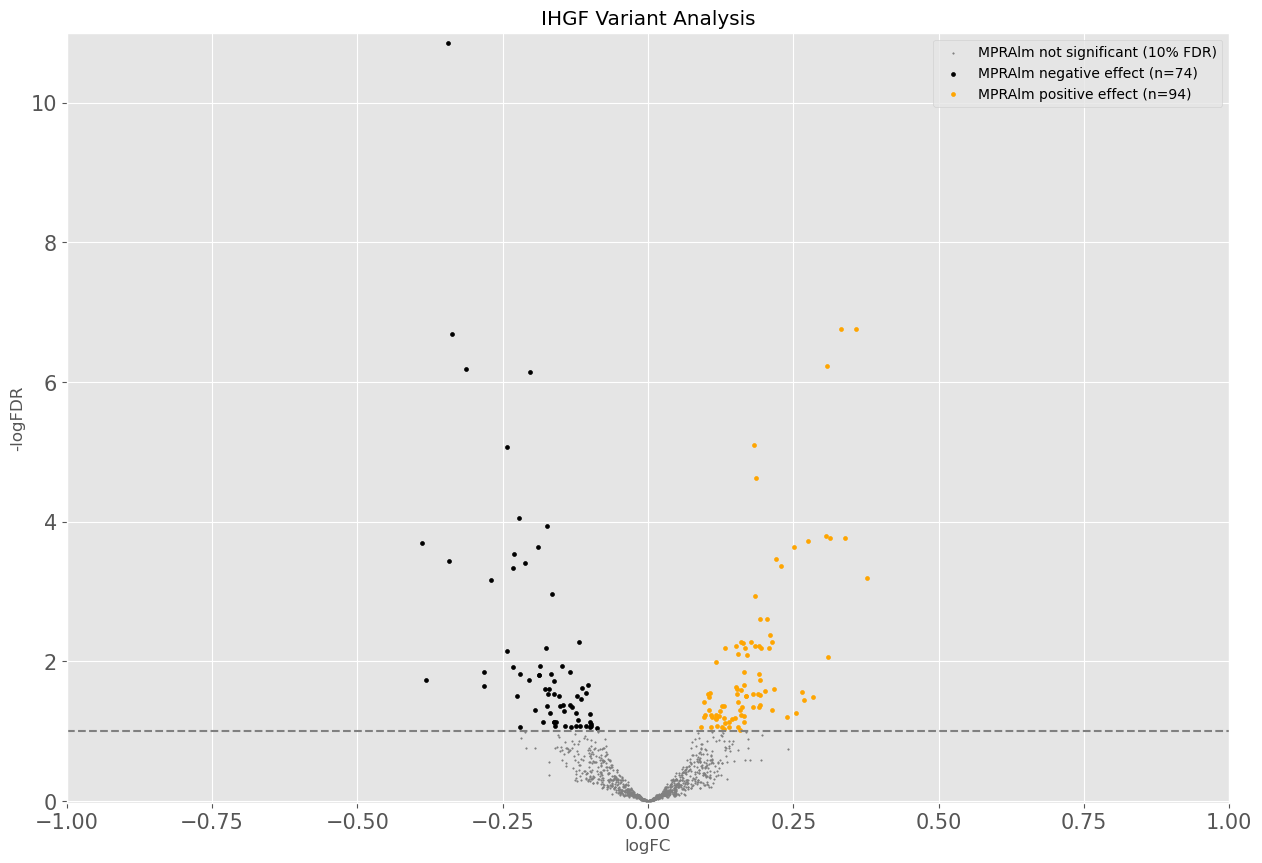

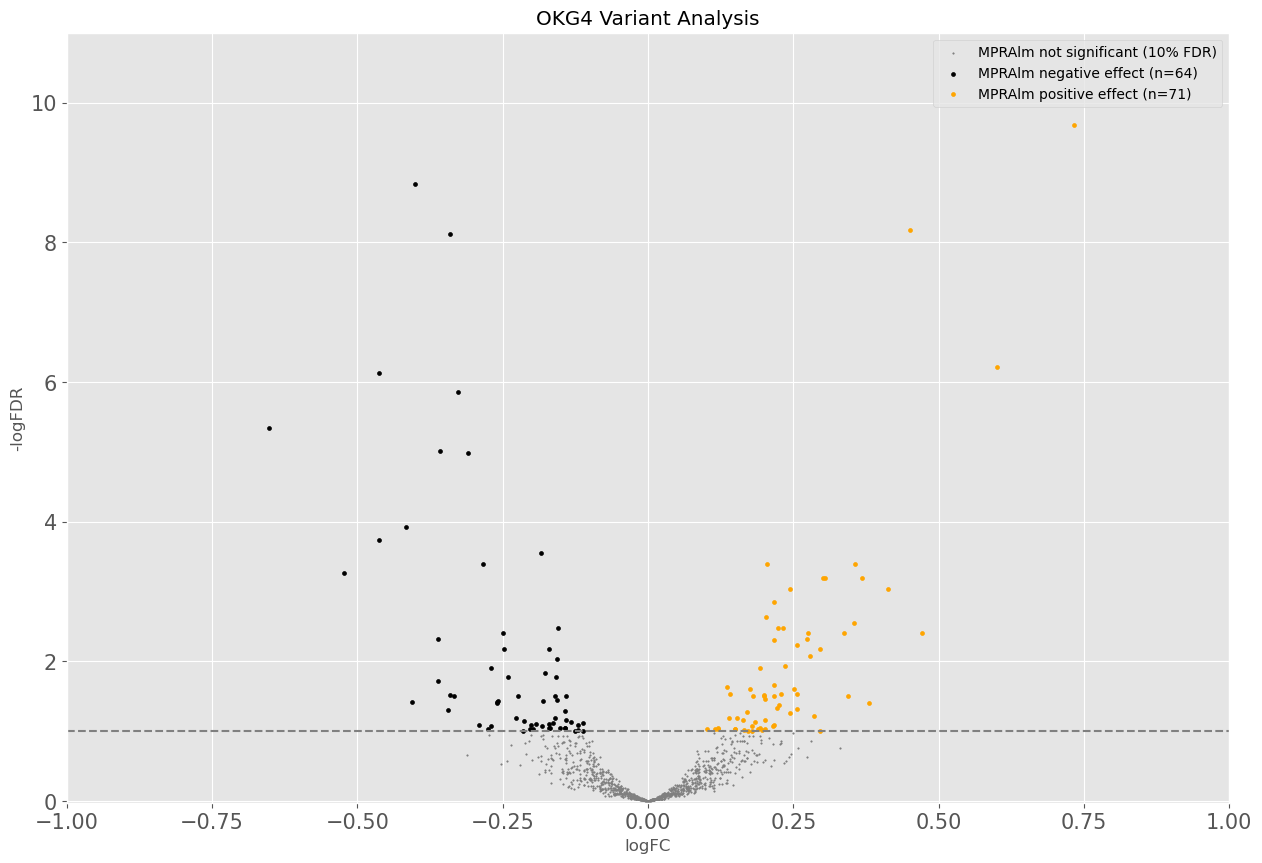

In [105]:
plot_volcano(huvec_variant_df, title="HUVEC Variant Analysis", logFC_col="logFC", adj_p_val_col="adj.P.Val")
plot_volcano(ihgf_variant_df, title="IHGF Variant Analysis", logFC_col="logFC", adj_p_val_col="adj.P.Val")
plot_volcano(okg4_variant_df, title="OKG4 Variant Analysis", logFC_col="logFC", adj_p_val_col="adj.P.Val")

### AI supported analysis

#### Generate a merged dataframe

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import plot as upset_plot
from upsetplot import from_contents

# --- 1. Combine variant tables with the additional_info_table ---
print("\n--- Step 1: Combining variant tables and merging with additional info ---")

# Add a 'cell_type' column to each individual DataFrame
huvec_variant_df['cell_type'] = 'HUVEC'
ihgf_variant_df['cell_type'] = 'IHGF'
okg4_variant_df['cell_type'] = 'OKG4'

# Concatenate all three variant dataframes into a single DataFrame
combined_variant_df = pd.concat([huvec_variant_df, ihgf_variant_df, okg4_variant_df], ignore_index=True)
print(f"Combined variant data: {len(combined_variant_df)} rows.")

# Merge with variant_map to get ALT and REF sequences
# 'variant_id' in combined_variant_df matches 'ID' in variant_map_df
merged_df = pd.merge(combined_variant_df, variant_map_df, left_on='variant_id', right_on='ID', how='left')
# Drop the redundant 'ID' column from variant_map after merge
merged_df = merged_df.drop(columns=['ID'])
print(f"Merged with variant_map: {len(merged_df)} rows.")

# Merge with additional_info_table for ALT sequences
# We rename columns in additional_info_table_df before merging to avoid conflicts
# and ensure clear distinction between ALT and REF info.
merged_df = pd.merge(
    merged_df,
    additional_info_table_df.rename(columns={
        'SequenceName': 'ALT',
        'SequenceName_long': 'SequenceName_long_ALT',
        'Sequence': 'Sequence_ALT',
        'label': 'label_ALT'
    }),
    on='ALT', # Merge on the 'ALT' column
    how='left'
)
print(f"Merged with additional_info_table for ALT: {len(merged_df)} rows.")

# Merge with additional_info_table for REF sequences
merged_df = pd.merge(
    merged_df,
    additional_info_table_df.rename(columns={
        'SequenceName': 'REF',
        'SequenceName_long': 'SequenceName_long_REF',
        'Sequence': 'Sequence_REF',
        'label': 'label_REF'
    }),
    on='REF', # Merge on the 'REF' column
    how='left'
)
print(f"Merged with additional_info_table for REF: {len(merged_df)} rows.")

print("\nHead of the combined and merged DataFrame:")
print(merged_df.head())
print(f"Final columns: {merged_df.columns.tolist()}")


--- Step 1: Combining variant tables and merging with additional info ---
Combined variant data: 3467 rows.
Merged with variant_map: 3467 rows.
Merged with additional_info_table for ALT: 3467 rows.
Merged with additional_info_table for REF: 3467 rows.

Head of the combined and merged DataFrame:
      logFC   AveExpr         t       P.Value     adj.P.Val          B  \
0 -0.756618  0.972043 -9.550919  1.530336e-20  1.762947e-17  35.704508   
1 -0.769873  1.904519 -6.937164  1.366467e-11  7.870852e-09  15.749036   
2 -0.508003 -0.260897 -6.154816  1.460896e-09  5.609841e-07  11.394024   
3  0.502012 -0.494585  5.766423  1.639914e-08  4.722951e-06   9.060193   
4 -0.301715 -0.291080 -5.186290  2.667567e-07  6.146075e-05   6.438147   

         variant_id mpralm_true cell_type               ALT               REF  \
0  CB_404305_001354    negative     HUVEC  CB_404305_001354  CB_404305_001954   
1  CB_404305_001324    negative     HUVEC  CB_404305_001324  CB_404305_001940   
2  CB_404305_00

In [107]:
merged_df.columns
merged_df

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,mpralm_true,cell_type,ALT,REF,SequenceName_long_ALT,Sequence_ALT,label_ALT,SequenceName_long_REF,Sequence_REF,label_REF
0,-0.756618,0.972043,-9.550919,1.530336e-20,1.762947e-17,35.704508,CB_404305_001354,negative,HUVEC,CB_404305_001354,CB_404305_001954,V_SNV_ALT:hg38_positive:chr9:130271610-1302718...,AGGACCGGATCAACTTTCCCACATTCCTACTTTTTGGCACTGGTAG...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr9:130271610-1302718...,AGGACCGGATCAACTTTCCCACATTCCTACTTTTTGGCACTGGTAG...,V_SNV_REF
1,-0.769873,1.904519,-6.937164,1.366467e-11,7.870852e-09,15.749036,CB_404305_001324,negative,HUVEC,CB_404305_001324,CB_404305_001940,V_SNV_ALT:hg38_positive:chr6:160804703-1608049...,AGGACCGGATCAACTTCGGGCAGCCTCCCAAGCCAGAGTAGGTTCA...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr6:160804703-1608049...,AGGACCGGATCAACTTCGGGCAGCCTCCCAAGCCAGAGTAGGTTCA...,V_SNV_REF
2,-0.508003,-0.260897,-6.154816,1.460896e-09,5.609841e-07,11.394024,CB_404305_000912,negative,HUVEC,CB_404305_000912,CB_404305_001696,V_SNV_ALT:hg38_positive:chr3:163450698-1634508...,AGGACCGGATCAACTTTTTGTAATAACTAGAAATCAGGTGGAAGAT...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr3:163450769-1634509...,AGGACCGGATCAACTGCTAACAATTGAAGGCAGTGGCATTCCATTT...,V_SNV_REF
3,0.502012,-0.494585,5.766423,1.639914e-08,4.722951e-06,9.060193,CB_404305_002051,positive,HUVEC,CB_404305_002051,CB_404305_002052,LINC01192_rs11714750_alt_C,AGGACCGGATCAACTAAGACAAATCTAGTTATGATCAAATAGTTTG...,LINC01192_rs11714750_alt_C,LINC01192_rs11714750_ref_G,AGGACCGGATCAACTAAGACAAATCTAGTTATGATCAAATAGTTTG...,LINC01192_rs11714750_ref_G
4,-0.301715,-0.291080,-5.186290,2.667567e-07,6.146075e-05,6.438147,CB_404305_001235,negative,HUVEC,CB_404305_001235,CB_404305_001878,V_SNV_ALT:hg38_positive:chr5:173923886-1739240...,AGGACCGGATCAACTAAAAATAGCCTTCCTGCTTGCTGGTTTGTTG...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr5:173923886-1739240...,AGGACCGGATCAACTAAAAATAGCCTTCCTGCTTGCTGGTTTGTTG...,V_SNV_REF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3462,0.009215,-0.222412,0.226051,8.212059e-01,9.333387e-01,-7.014036,CB_404305_001394,neutral,OKG4,CB_404305_001394,CB_404305_001972,V_SNV_ALT:hg38_positive:chr9:22092824-22093024...,AGGACCGGATCAACTCAGTTCTGCTCTGATCTTAGTTGTTTCTTGC...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr9:22092824-22093024...,AGGACCGGATCAACTCAGTTCTGCTCTGATCTTAGTTGTTTCTTGC...,V_SNV_REF
3463,-0.011758,-0.037459,-0.261174,7.940090e-01,9.266679e-01,-7.015495,CB_404305_002385,neutral,OKG4,CB_404305_002385,CB_404305_002387,LINC01192_rs6810174_alt_C,AGGACCGGATCAACTTGTCACCCAGGCTGGAATGCAGTGGTGCGAC...,LINC01192_rs6810174_alt_C,LINC01192_rs6810174_ref_A,AGGACCGGATCAACTTGTCACCCAGGCTGGAATGCAGTGGTGCGAC...,LINC01192_rs6810174_ref_A
3464,-0.008037,-0.777540,-0.180815,8.565472e-01,9.447331e-01,-7.020217,CB_404305_000571,neutral,OKG4,CB_404305_000571,CB_404305_001477,V_SNV_ALT:hg38_positive:chr1:161217774-1612179...,AGGACCGGATCAACTAACCCTCAAGCTTCCTATCCTAGCCTGACCC...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr1:161217774-1612179...,AGGACCGGATCAACTAACCCTCAAGCTTCCTATCCTAGCCTGACCC...,V_SNV_REF
3465,-0.006074,-0.599783,-0.136895,8.911397e-01,9.573340e-01,-7.025549,CB_404305_001303,neutral,OKG4,CB_404305_001303,CB_404305_001927,V_SNV_ALT:hg38_positive:chr6:160778754-1607789...,AGGACCGGATCAACTTTAATACTTTTAGAGGCCCTCAAAATCACAA...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr6:160778754-1607789...,AGGACCGGATCAACTTTAATACTTTTAGAGGCCCTCAAAATCACAA...,V_SNV_REF


### Upset plot for the variant presence in each cell-type


--- Step 2: Generating Upset plot for variant presence across cell types ---


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

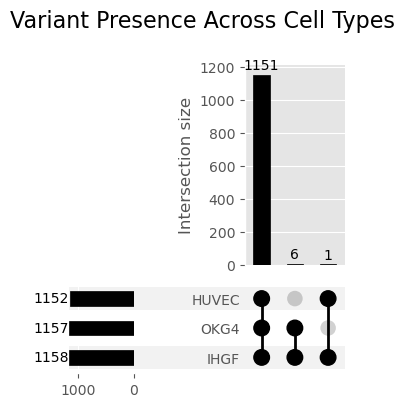

In [108]:
# --- 2. Check which variants are in all 3 cell-types using a simple upset plot ---
print("\n--- Step 2: Generating Upset plot for variant presence across cell types ---")

# Get unique variant_ids for each cell type
huvec_variants = set(huvec_variant_df['variant_id'])
ihgf_variants = set(ihgf_variant_df['variant_id'])
okg4_variants = set(okg4_variant_df['variant_id'])

# Prepare data for UpSetPlot
variant_sets = {
    'HUVEC': huvec_variants,
    'IHGF': ihgf_variants,
    'OKG4': okg4_variants
}

# Convert the dictionary of sets to the format required by UpSetPlot
upset_data_presence = from_contents(variant_sets)

plt.figure(figsize=(10, 6))
upset_plot(upset_data_presence, show_counts=True, sort_by='cardinality')
plt.suptitle('Variant Presence Across Cell Types', y=1.02, fontsize=16)
plt.show()


### Pairwise correlation


--- Step 3: Plotting pairwise correlation of logFC for common variants ---
Number of variants common to all three cell types for correlation analysis: 1151


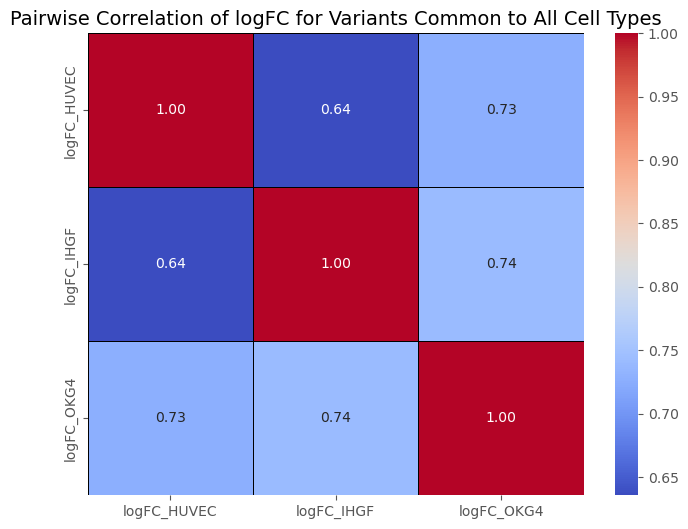

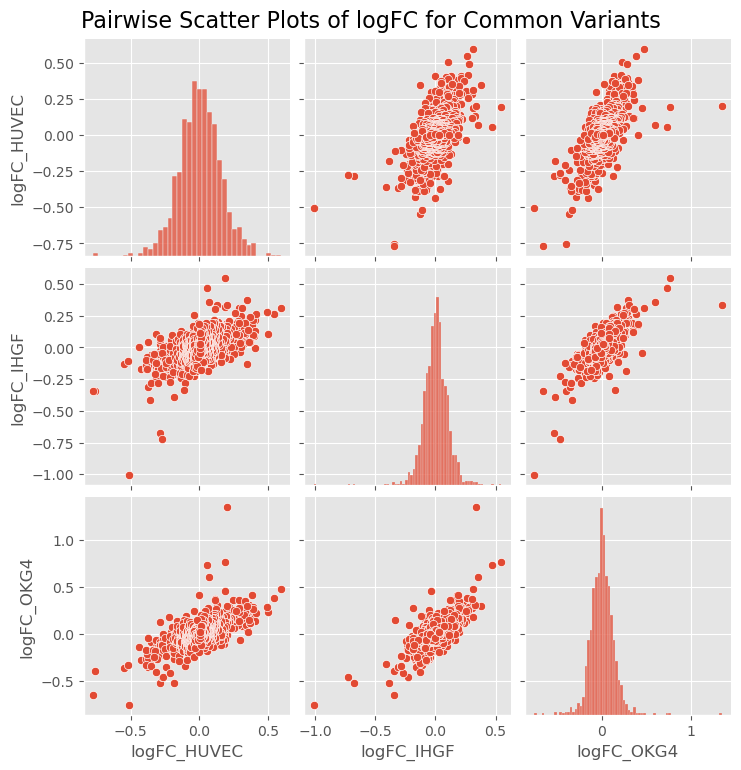

In [109]:
# --- 3. Plot the pairwise correlation between the three cell-type variant effects of the variants which are within each cell-types ---
print("\n--- Step 3: Plotting pairwise correlation of logFC for common variants ---")

# Find the intersection of variant IDs present in all three cell types
common_variants = list(huvec_variants.intersection(ihgf_variants, okg4_variants))
print(f"Number of variants common to all three cell types for correlation analysis: {len(common_variants)}")

if len(common_variants) >= 2: # Need at least 2 common variants for correlation
    # Filter each original DataFrame to include only these common variants
    huvec_logfc_common = huvec_variant_df[huvec_variant_df['variant_id'].isin(common_variants)][['variant_id', 'logFC']]
    ihgf_logfc_common = ihgf_variant_df[ihgf_variant_df['variant_id'].isin(common_variants)][['variant_id', 'logFC']]
    okg4_logfc_common = okg4_variant_df[okg4_variant_df['variant_id'].isin(common_variants)][['variant_id', 'logFC']]

    # Merge these filtered DataFrames on 'variant_id' to get logFC values side-by-side
    correlation_data = pd.merge(huvec_logfc_common, ihgf_logfc_common, on='variant_id', suffixes=('_HUVEC', '_IHGF'))
    correlation_data = pd.merge(correlation_data, okg4_logfc_common, on='variant_id')
    correlation_data = correlation_data.rename(columns={'logFC': 'logFC_OKG4'}) # Rename for consistency

    # Calculate the correlation matrix
    corr_matrix = correlation_data[['logFC_HUVEC', 'logFC_IHGF', 'logFC_OKG4']].corr()

    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
    plt.title('Pairwise Correlation of logFC for Variants Common to All Cell Types', fontsize=14)
    plt.show()

    # Optional: Pairplot for detailed scatter plots and distributions
    sns.pairplot(correlation_data[['logFC_HUVEC', 'logFC_IHGF', 'logFC_OKG4']])
    plt.suptitle('Pairwise Scatter Plots of logFC for Common Variants', y=1.02, fontsize=16)
    plt.show()

else:
    print("Not enough common variants (less than 2) to plot pairwise correlation. Skipping correlation plots.")



--- Step 4: Generating Upset plot for significant variants (adj.P.Val < 0.05) ---


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

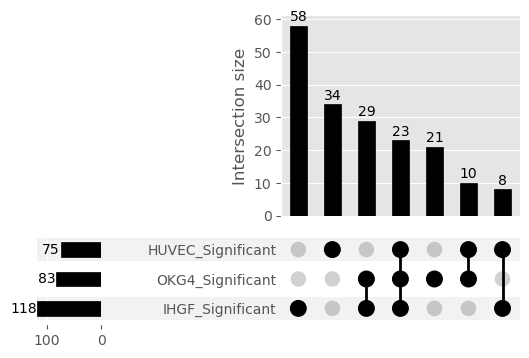

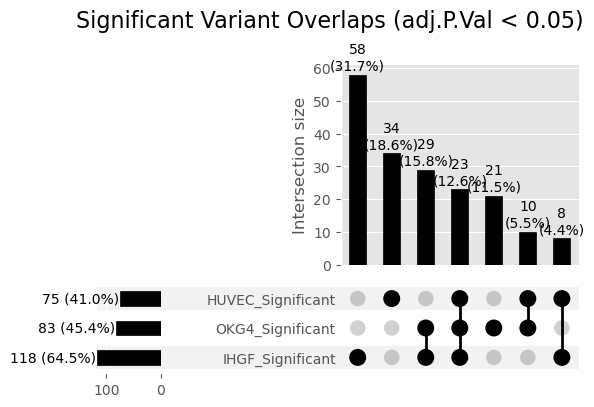

In [110]:
SIGNIFICANCE_THRESHOLD = 0.05
# --- 4. Define a customizable significance threshold and generate another upset plot ---
print(f"\n--- Step 4: Generating Upset plot for significant variants (adj.P.Val < {SIGNIFICANCE_THRESHOLD}) ---")

# Filter for significant variants based on 'adj.P.Val'
huvec_sig_variants = set(huvec_variant_df[huvec_variant_df['adj.P.Val'] < SIGNIFICANCE_THRESHOLD]['variant_id'])
ihgf_sig_variants = set(ihgf_variant_df[ihgf_variant_df['adj.P.Val'] < SIGNIFICANCE_THRESHOLD]['variant_id'])
okg4_sig_variants = set(okg4_variant_df[okg4_variant_df['adj.P.Val'] < SIGNIFICANCE_THRESHOLD]['variant_id'])

significant_variant_sets = {
    'HUVEC_Significant': huvec_sig_variants,
    'IHGF_Significant': ihgf_sig_variants,
    'OKG4_Significant': okg4_sig_variants
}

upset_data_significant = from_contents(significant_variant_sets)

plt.figure(figsize=(10, 6))
upset_plot(upset_data_significant, show_counts=True, sort_by='cardinality')
upset_plot(upset_data_significant, show_counts=True, show_percentages=True, sort_by='cardinality')
plt.suptitle(f'Significant Variant Overlaps (adj.P.Val < {SIGNIFICANCE_THRESHOLD})', y=1.02, fontsize=16)
plt.show()

#### For the 11 variants significant in all three cell-types: check their correlation (scatter plot)


--- Investigating correlation for variants significant in ALL 3 cell types (adj.P.Val < 0.05) ---
Number of variants significant in all three cell types: 23

Head of logFC data for variants significant in all 3 cell types:
         variant_id  logFC_HUVEC  logFC_IHGF  logFC_OKG4
0  CB_404305_001354    -0.756618   -0.343682   -0.400086
1  CB_404305_001324    -0.769873   -0.342751   -0.652029
2  CB_404305_000912    -0.508003   -1.009956   -0.756685
3  CB_404305_001235    -0.301715   -0.203609   -0.169577
4  CB_404305_002111    -0.359928   -0.412570   -0.326485


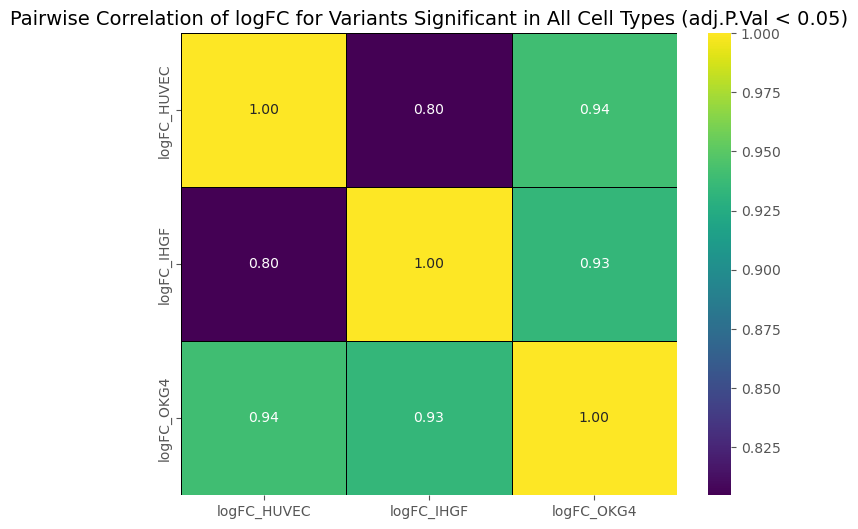

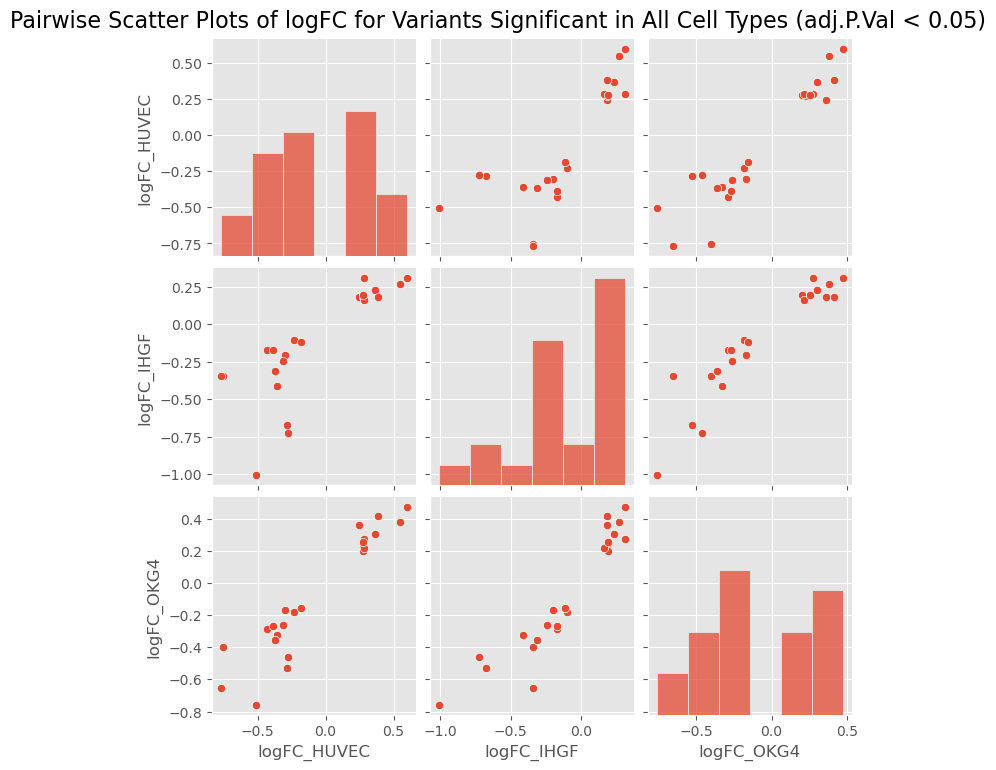

In [111]:
print(f"\n--- Investigating correlation for variants significant in ALL 3 cell types (adj.P.Val < {SIGNIFICANCE_THRESHOLD}) ---")

# 1. Identify variants significant in all three cell types
# First, get the sets of significant variants for each cell type (re-calculating for clarity, but already done in step 4)
huvec_sig_variants = set(huvec_variant_df[huvec_variant_df['adj.P.Val'] < SIGNIFICANCE_THRESHOLD]['variant_id'])
ihgf_sig_variants = set(ihgf_variant_df[ihgf_variant_df['adj.P.Val'] < SIGNIFICANCE_THRESHOLD]['variant_id'])
okg4_sig_variants = set(okg4_variant_df[okg4_variant_df['adj.P.Val'] < SIGNIFICANCE_THRESHOLD]['variant_id'])

# Find the intersection (variants significant in ALL three)
common_significant_variants = list(huvec_sig_variants.intersection(ihgf_sig_variants, okg4_sig_variants))

print(f"Number of variants significant in all three cell types: {len(common_significant_variants)}")

if len(common_significant_variants) >= 2: # Need at least 2 variants for meaningful correlation
    # 2. Filter logFC for these specific variants from the original dataframes
    huvec_common_sig_logfc = huvec_variant_df[huvec_variant_df['variant_id'].isin(common_significant_variants)][['variant_id', 'logFC']]
    ihgf_common_sig_logfc = ihgf_variant_df[ihgf_variant_df['variant_id'].isin(common_significant_variants)][['variant_id', 'logFC']]
    okg4_common_sig_logfc = okg4_variant_df[okg4_variant_df['variant_id'].isin(common_significant_variants)][['variant_id', 'logFC']]

    # Merge these DataFrames to align logFC values for common significant variants
    correlation_common_sig_df = pd.merge(huvec_common_sig_logfc, ihgf_common_sig_logfc, on='variant_id', suffixes=('_HUVEC', '_IHGF'))
    correlation_common_sig_df = pd.merge(correlation_common_sig_df, okg4_common_sig_logfc, on='variant_id')
    correlation_common_sig_df = correlation_common_sig_df.rename(columns={'logFC': 'logFC_OKG4'}) # Rename for consistency

    print("\nHead of logFC data for variants significant in all 3 cell types:")
    print(correlation_common_sig_df.head())

    # 3. Plot pairwise correlation for these variants
    corr_matrix_common_sig = correlation_common_sig_df[['logFC_HUVEC', 'logFC_IHGF', 'logFC_OKG4']].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix_common_sig, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, linecolor='black')
    plt.title(f'Pairwise Correlation of logFC for Variants Significant in All Cell Types (adj.P.Val < {SIGNIFICANCE_THRESHOLD})', fontsize=14)
    plt.show()

    sns.pairplot(correlation_common_sig_df[['logFC_HUVEC', 'logFC_IHGF', 'logFC_OKG4']])
    plt.suptitle(f'Pairwise Scatter Plots of logFC for Variants Significant in All Cell Types (adj.P.Val < {SIGNIFICANCE_THRESHOLD})', y=1.02, fontsize=16)
    plt.show()

else:
    print("Not enough variants (less than 2) found to be significant in all three cell types to plot their pairwise correlation.")
    print("Consider adjusting the SIGNIFICANCE_THRESHOLD if you expect more common significant variants.")


TODO: generate a plot which shows the proportion of significant variants over tested variants for each cell-type

### Compare the variant effect direction between the cell-types


--- Step 5: Generating Upset plots for positive and negative logFC variants ---


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

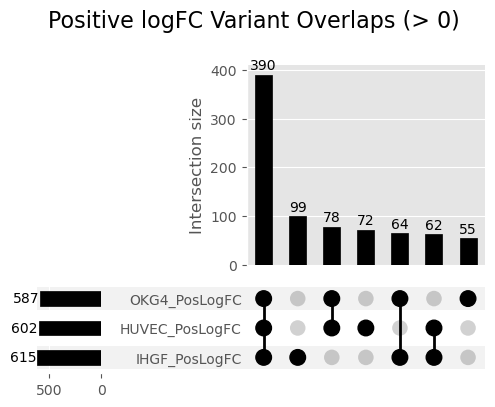

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

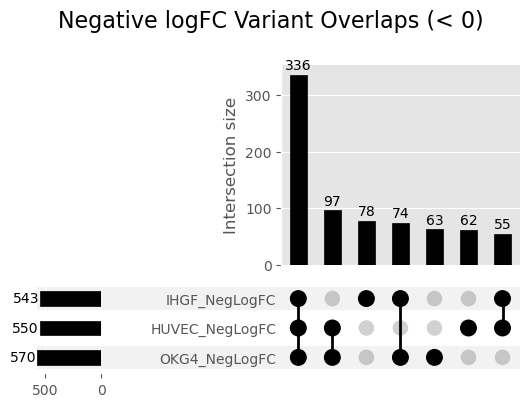


All requested analyses and plots have been generated.


In [112]:
# --- 5. Split variants into increasing (positive logFC) and decreasing (negative logFC) and generate upset plots ---
print("\n--- Step 5: Generating Upset plots for positive and negative logFC variants ---")

# Positive logFC variants (increasing effect)
huvec_pos_logfc_variants = set(huvec_variant_df[huvec_variant_df['logFC'] > 0]['variant_id'])
ihgf_pos_logfc_variants = set(ihgf_variant_df[ihgf_variant_df['logFC'] > 0]['variant_id'])
okg4_pos_logfc_variants = set(okg4_variant_df[okg4_variant_df['logFC'] > 0]['variant_id'])

pos_logfc_variant_sets = {
    'HUVEC_PosLogFC': huvec_pos_logfc_variants,
    'IHGF_PosLogFC': ihgf_pos_logfc_variants,
    'OKG4_PosLogFC': okg4_pos_logfc_variants
}

upset_data_pos_logfc = from_contents(pos_logfc_variant_sets)

plt.figure(figsize=(10, 6))
upset_plot(upset_data_pos_logfc, show_counts=True, sort_by='cardinality')
plt.suptitle('Positive logFC Variant Overlaps (> 0)', y=1.02, fontsize=16)
plt.show()

# Negative logFC variants (decreasing effect)
huvec_neg_logfc_variants = set(huvec_variant_df[huvec_variant_df['logFC'] < 0]['variant_id'])
ihgf_neg_logfc_variants = set(ihgf_variant_df[ihgf_variant_df['logFC'] < 0]['variant_id'])
okg4_neg_logfc_variants = set(okg4_variant_df[okg4_variant_df['logFC'] < 0]['variant_id'])

neg_logfc_variant_sets = {
    'HUVEC_NegLogFC': huvec_neg_logfc_variants,
    'IHGF_NegLogFC': ihgf_neg_logfc_variants,
    'OKG4_NegLogFC': okg4_neg_logfc_variants
}

upset_data_neg_logfc = from_contents(neg_logfc_variant_sets)

plt.figure(figsize=(10, 6))
upset_plot(upset_data_neg_logfc, show_counts=True, sort_by='cardinality')
plt.suptitle('Negative logFC Variant Overlaps (< 0)', y=1.02, fontsize=16)
plt.show()

print("\nAll requested analyses and plots have been generated.")

### Variant effect direction in one upset plot


--- Generating Upset plot for Significant Positive/Negative Effects (adj.P.Val < 0.05) ---


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1200x800 with 0 Axes>

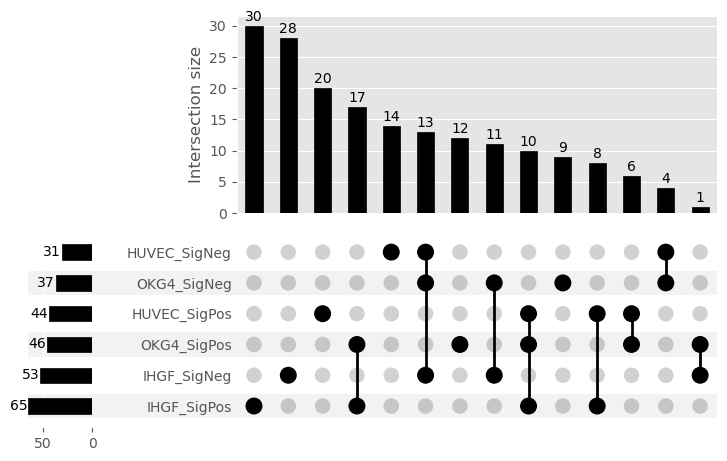

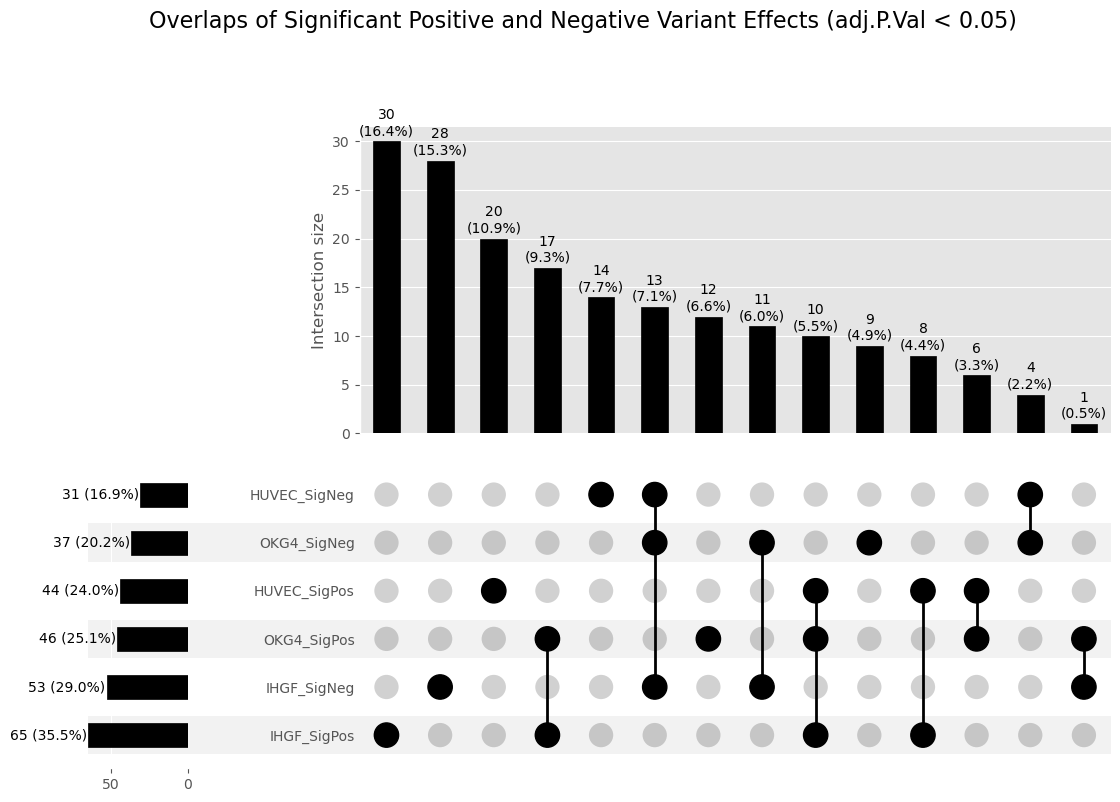

In [113]:
print(f"\n--- Generating Upset plot for Significant Positive/Negative Effects (adj.P.Val < {SIGNIFICANCE_THRESHOLD}) ---")

# Define cell types and prefixes
cell_types = ['HUVEC', 'IHGF', 'OKG4']
variant_effect_sets = {}

for cell_type in cell_types:
    logFC_col = f'logFC_{cell_type}'
    adj_pvalue_col = f'adj_pvalue_{cell_type}'

    # Filter for significant positive effects
    sig_pos_variants = set(
        enriched_matrix[
            (enriched_matrix[adj_pvalue_col] < SIGNIFICANCE_THRESHOLD) &
            (enriched_matrix[logFC_col] > 0)
        ]['variant_id'].dropna() # Dropna handles cases where variant_id might be NaN (though unlikely)
    )
    variant_effect_sets[f'{cell_type}_SigPos'] = sig_pos_variants

    # Filter for significant negative effects
    sig_neg_variants = set(
        enriched_matrix[
            (enriched_matrix[adj_pvalue_col] < SIGNIFICANCE_THRESHOLD) &
            (enriched_matrix[logFC_col] < 0)
        ]['variant_id'].dropna()
    )
    variant_effect_sets[f'{cell_type}_SigNeg'] = sig_neg_variants

# Convert the dictionary of sets to the format required by UpSetPlot
upset_data_sig_effects = from_contents(variant_effect_sets)

plt.figure(figsize=(12, 8)) # Adjust figure size for more sets
upset_plot(upset_data_sig_effects, show_counts=True, sort_by='cardinality')
upset_plot(upset_data_sig_effects, show_counts=True, show_percentages=True, element_size=50, sort_by='cardinality')
plt.suptitle(f'Overlaps of Significant Positive and Negative Variant Effects (adj.P.Val < {SIGNIFICANCE_THRESHOLD})', y=1.02, fontsize=16)
plt.show()

#### One variant is significant in OKG4 with positive effect and in IHGF with negative effect (SNV)

In [114]:
enriched_matrix['is_significant_positive_OKG4'] = (enriched_matrix['adj_pvalue_OKG4'] < SIGNIFICANCE_THRESHOLD) & (enriched_matrix['logFC_OKG4'] > 0)
enriched_matrix['is_significant_negative_OKG4'] = (enriched_matrix['adj_pvalue_OKG4'] < SIGNIFICANCE_THRESHOLD) & (enriched_matrix['logFC_OKG4'] < 0)
enriched_matrix['is_significant_positive_IHGF'] = (enriched_matrix['adj_pvalue_IHGF'] < SIGNIFICANCE_THRESHOLD) & (enriched_matrix['logFC_IHGF'] > 0)
enriched_matrix['is_significant_negative_IHGF'] = (enriched_matrix['adj_pvalue_IHGF'] < SIGNIFICANCE_THRESHOLD) & (enriched_matrix['logFC_IHGF'] < 0)
enriched_matrix['is_significant_positive_HUVEC'] = (enriched_matrix['adj_pvalue_HUVEC'] < SIGNIFICANCE_THRESHOLD) & (enriched_matrix['logFC_HUVEC'] > 0)
enriched_matrix['is_significant_negative_HUVEC'] = (enriched_matrix['adj_pvalue_HUVEC'] < SIGNIFICANCE_THRESHOLD) & (enriched_matrix['logFC_HUVEC'] < 0)

# get the variant which is significant_positive in OKG4 and negative significant in IHGF
enriched_matrix.loc[enriched_matrix['is_significant_positive_OKG4'] & enriched_matrix['is_significant_negative_IHGF']]

,variant_id,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,logFC_OKG4,adj_pvalue_OKG4,ALT,REF,SequenceName_long_ALT,...,SequenceName_long_REF,Sequence_REF,label_REF,variant_group,is_significant_positive_OKG4,is_significant_negative_OKG4,is_significant_positive_IHGF,is_significant_negative_IHGF,is_significant_positive_HUVEC,is_significant_negative_HUVEC
142,CB_404305_000647,0.064337,0.652689,-0.187763,0.015461,0.275738,0.003937,CB_404305_000647,CB_404305_001525,V_SNV_ALT:hg38_positive:chr17:43733105-4373330...,...,V_SNV_REF:hg38_positive:chr17:43733105-4373330...,AGGACCGGATCAACTTCTTGGGTTTCTGAGAGGTAGCTTCTAAACC...,V_SNV_REF,SNV,True,False,False,True,False,False


In [ ]:
enriched_matrix.columns

Index(['variant_id', 'logFC_HUVEC', 'adj_pvalue_HUVEC', 'logFC_IHGF',
       'adj_pvalue_IHGF', 'logFC_OKG4', 'adj_pvalue_OKG4', 'ALT', 'REF',
       'SequenceName_long_ALT', 'Sequence_ALT', 'label_ALT',
       'SequenceName_long_REF', 'Sequence_REF', 'label_REF', 'variant_group',
       'rsid', 'is_significant_positive_OKG4', 'is_significant_negative_OKG4',
       'is_significant_positive_IHGF', 'is_significant_negative_IHGF',
       'is_significant_positive_HUVEC', 'is_significant_negative_HUVEC'],
      dtype='object')

### Generate the interesting output: 
- Add for each of the cell-types is_significant_negative for more then one cell-type

In [137]:
# generate the additional columns:
# Create the 'at_least_two_negative' column
negative_cols = ['is_significant_negative_OKG4', 'is_significant_negative_IHGF', 'is_significant_negative_HUVEC']
enriched_matrix['significant_negative_effect_in_at_least_two'] = (enriched_matrix[negative_cols].sum(axis=1) >= 2)

# Create the 'at_least_two_positive' column
positive_cols = ['is_significant_positive_OKG4', 'is_significant_positive_IHGF', 'is_significant_positive_HUVEC']
enriched_matrix['significant_positive_effect_in_at_least_two'] = (enriched_matrix[positive_cols].sum(axis=1) >= 2)


In [138]:
# add the rsid column for matching with the gene information
enriched_matrix['rsid'] = enriched_matrix['SequenceName_long_ALT'].str.extract(r'(rs\d+)', expand=False)
enriched_matrix['rsid'].isna().sum()

0

In [116]:
# add the gene information:
first_rsid_to_gene_list_path = "/home/kisa/coding/periodontitis_MPRA_design/08072025_Periodontitis-MPRA_SNP_list_Agilent.csv"
first_rsid_to_gene_list_df = pd.read_csv(first_rsid_to_gene_list_path, sep=";")
first_rsid_to_gene_list_df.columns

first_rsid_to_gene_list_df.rename(columns={
    'name (hg19)': 'rsid',
    'gene': 'gene_name'
}, inplace=True)

first_rsid_to_gene_list_df = first_rsid_to_gene_list_df[['gene_name', 'rsid']].copy()
first_rsid_to_gene_list_df

,gene_name,rsid
0,ADAMTS7,rs10163145
1,ADAMTS7,rs10163145
2,ADAMTS7,rs11072803
3,ADAMTS7,rs11072803
4,ADAMTS7,rs11072804
...,...,...
1353,VAMP8,rs7605975
1354,VAMP8,rs900474921
1355,VAMP8,rs900474921
1356,VAMP8,rs900474921


#### Found some missing values and not proper rsids in the rsid column

In [117]:
first_rsid_set = set(first_rsid_to_gene_list_df['rsid'].to_list())

In [118]:
len(first_rsid_set)

582

In [131]:
first_rsid_to_gene_list_df

,gene_name,rsid
0,ADAMTS7,rs10163145
1,ADAMTS7,rs10163145
2,ADAMTS7,rs11072803
3,ADAMTS7,rs11072803
4,ADAMTS7,rs11072804
...,...,...
1353,VAMP8,rs7605975
1354,VAMP8,rs900474921
1355,VAMP8,rs900474921
1356,VAMP8,rs900474921


In [119]:
first_rsid_to_gene_list_deduplicated_df = first_rsid_to_gene_list_df.drop_duplicates(subset=['gene_name', 'rsid'])
first_rsid_to_gene_list_deduplicated_df

# remove missing rsid row
first_rsid_to_gene_list_deduplicated_df = first_rsid_to_gene_list_deduplicated_df[first_rsid_to_gene_list_deduplicated_df['rsid'].notna()]
first_rsid_to_gene_list_deduplicated_df

# remove PF4
first_rsid_to_gene_list_deduplicated_df = first_rsid_to_gene_list_deduplicated_df[first_rsid_to_gene_list_deduplicated_df['rsid'] != 'PF4']
first_rsid_to_gene_list_deduplicated_df
first_rsid_set_modified_deduplicated = set(first_rsid_to_gene_list_deduplicated_df['rsid'].to_list())

In [120]:
first_rsid_set_modified_deduplicated

{'rs1004638',
 'rs10054063',
 'rs1009',
 'rs10116277',
 'rs10163145',
 'rs10172544',
 'rs10175792',
 'rs10176176',
 'rs10179195',
 'rs10187424',
 'rs10198569',
 'rs10206961',
 'rs10217586',
 'rs10454768',
 'rs10454769',
 'rs10511701',
 'rs10513655',
 'rs10513656',
 'rs10513657',
 'rs10516107',
 'rs1058588',
 'rs10700825',
 'rs10733376',
 'rs10738606',
 'rs10738607',
 'rs10738608',
 'rs10738609',
 'rs10738610',
 'rs10757269',
 'rs10757271',
 'rs10757272',
 'rs10757273',
 'rs10757274',
 'rs10757275',
 'rs10757277',
 'rs10757278',
 'rs10757279',
 'rs1078004',
 'rs10811652',
 'rs10811653',
 'rs10811654',
 'rs10811656',
 'rs1084653',
 'rs10936569',
 'rs11072803',
 'rs11072804',
 'rs11072805',
 'rs11072806',
 'rs1115476',
 'rs1119180',
 'rs1120238',
 'rs112299234',
 'rs112321636',
 'rs11339888',
 'rs11344703',
 'rs11350741',
 'rs113932433',
 'rs115002293',
 'rs11631955',
 'rs11632102',
 'rs11634042',
 'rs11634450',
 'rs11638321',
 'rs11639044',
 'rs11650233',
 'rs11721928',
 'rs11722954',
 '

In [121]:
second_rsid_to_gene_list_path = "/home/kisa/coding/periodontitis_MPRA_design/08072025_Periodontitis-MPRA_additional_SNPs_Agilent.csv"
second_rsid_to_gene_list_df = pd.read_csv(second_rsid_to_gene_list_path, sep=";", header=None)
second_rsid_to_gene_list_df.drop(columns=[2,3,4], inplace=True)
second_rsid_to_gene_list_df.columns = ['gene_name', 'rsid']
second_rsid_to_gene_list_df

,gene_name,rsid
0,SIGLEC5,rs11084095
1,SIGLEC5,rs11880807
2,SIGLEC5,rs12461706
3,SIGLEC5,rs34984145
4,SIGLEC5,rs3829655
5,SIGLEC5,rs4284742
6,SIGLEC5,rs4801882
7,HMCN2,rs10988663
8,HMCN2,rs115281761
9,HMCN2,rs140875954


In [122]:
second_rsid_set = set(second_rsid_to_gene_list_df['rsid'].to_list())

In [123]:
len(second_rsid_set)

42

In [124]:
first_rsid_set.intersection(second_rsid_set)

set()

In [129]:
# concat:
gene_name_rsid_table = pd.concat([first_rsid_to_gene_list_deduplicated_df, second_rsid_to_gene_list_df], ignore_index=True)
gene_name_rsid_table.duplicated(subset=['rsid']).sum()
gene_name_rsid_table.shape[0]

622

#### Match what is possible and send both lists

In [139]:
matchable_variants_rsids = enriched_matrix.merge(gene_name_rsid_table, on='rsid', how='inner') # 728
matchable_variants_rsids

,variant_id,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,logFC_OKG4,adj_pvalue_OKG4,ALT,REF,SequenceName_long_ALT,...,is_significant_positive_OKG4,is_significant_negative_OKG4,is_significant_positive_IHGF,is_significant_negative_IHGF,is_significant_positive_HUVEC,is_significant_negative_HUVEC,rsid,significant_negative_effect_in_at_least_two,significant_positive_effect_in_at_least_two,gene_name
0,CB_404305_000413,0.095099,0.401457,-0.031695,0.701917,0.019382,0.879174,CB_404305_000413,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783346-78783...,...,False,False,False,False,False,False,rs71148563,False,False,ADAMTS7
1,CB_404305_000414,0.073323,0.546036,-0.079418,0.261043,-0.004801,0.973792,CB_404305_000414,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,...,False,False,False,False,False,False,rs71148563,False,False,ADAMTS7
2,CB_404305_000415,-0.108604,0.342878,-0.122103,0.030997,-0.123463,0.147734,CB_404305_000415,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,...,False,False,False,True,False,False,rs71148563,False,False,ADAMTS7
3,CB_404305_000416,0.047242,0.722612,-0.051763,0.488595,0.045334,0.670414,CB_404305_000416,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783350-78783...,...,False,False,False,False,False,False,rs71148563,False,False,ADAMTS7
4,CB_404305_000418,0.028593,0.831222,0.060408,0.379118,0.059736,0.539710,CB_404305_000418,CB_404305_000523,V_INDEL_ALT:hg38_positive:chr15:78793253-78793...,...,False,False,False,False,False,False,rs55739451,False,False,ADAMTS7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,CB_404305_001470,0.122454,0.372787,0.087760,0.392798,0.035723,0.841275,CB_404305_001470,CB_404305_002002,V_SNV_ALT:hg38_positive:chr9:22124644-22124844...,...,False,False,False,False,False,False,rs4977575,False,False,ANRIL
724,CB_404305_001471,0.026270,0.910734,0.002871,0.987797,0.056996,0.699904,CB_404305_001471,CB_404305_002003,V_SNV_ALT:hg38_positive:chr9:22125247-22125447...,...,False,False,False,False,False,False,rs1333048,False,False,ANRIL
725,CB_404305_001472,-0.121573,0.564789,-0.057222,0.625704,-0.002823,0.990604,CB_404305_001472,CB_404305_002003,V_SNV_ALT:hg38_positive:chr9:22125247-22125447...,...,False,False,False,False,False,False,rs1333048,False,False,ANRIL
726,CB_404305_001473,-0.043753,0.857047,-0.095146,0.466232,0.017787,0.944733,CB_404305_001473,CB_404305_002004,V_SNV_ALT:hg38_positive:chr9:22125403-22125603...,...,False,False,False,False,False,False,rs1333049,False,False,ANRIL


In [141]:
not_matchable_variants_rsids = enriched_matrix[~enriched_matrix['rsid'].isin(gene_name_rsid_table['rsid'].to_list())] # 430
not_matchable_variants_rsids['gene_name'] = "NA"
# not_matchable_variants_rsids['rsid'].to_list()
not_matchable_variants_rsids

/tmp/ipykernel_853154/3285459473.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  not_matchable_variants_rsids['gene_name'] = "NA"


,variant_id,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,logFC_OKG4,adj_pvalue_OKG4,ALT,REF,SequenceName_long_ALT,...,is_significant_positive_OKG4,is_significant_negative_OKG4,is_significant_positive_IHGF,is_significant_negative_IHGF,is_significant_positive_HUVEC,is_significant_negative_HUVEC,rsid,significant_negative_effect_in_at_least_two,significant_positive_effect_in_at_least_two,gene_name
47,CB_404305_000463,-0.375786,0.033743,-0.149649,0.169493,-0.258395,0.036960,CB_404305_000463,CB_404305_000548,V_INDEL_ALT:hg38_positive:chr4:73928957-739291...,...,False,True,False,False,False,True,rs33980625,True,False,NA
48,CB_404305_000464,0.005082,0.984452,0.085779,0.499263,0.090102,0.630086,CB_404305_000464,CB_404305_000549,V_INDEL_ALT:hg38_positive:chr4:73948309-739485...,...,False,False,False,False,False,False,rs11308929,False,False,NA
49,CB_404305_000465,0.136637,0.459030,0.101084,0.433686,0.165716,0.266436,CB_404305_000465,CB_404305_000549,V_INDEL_ALT:hg38_positive:chr4:73948310-739485...,...,False,False,False,False,False,False,rs11308929,False,False,NA
50,CB_404305_000466,-0.146504,0.537448,-0.077997,0.627524,-0.290428,0.082616,CB_404305_000466,CB_404305_000549,V_INDEL_ALT:hg38_positive:chr4:73948311-739485...,...,False,False,False,False,False,False,rs11308929,False,False,NA
51,CB_404305_000467,-0.190875,0.144855,-0.100041,0.225565,-0.105061,0.345210,CB_404305_000467,CB_404305_000550,V_INDEL_ALT:hg38_positive:chr4:73989997-739901...,...,False,False,False,False,False,False,rs35033774,False,False,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,CB_404305_002535,0.007600,0.970469,-0.006009,0.969653,0.016015,0.937603,CB_404305_002535,CB_404305_002536,LINC01192_rs9855879_alt_A,...,False,False,False,False,False,False,rs9855879,False,False,NA
1154,CB_404305_002537,0.097124,0.614316,-0.023912,0.866416,0.068919,0.724334,CB_404305_002537,CB_404305_002538,LINC01192_rs9857851_alt_A,...,False,False,False,False,False,False,rs9857851,False,False,NA
1155,CB_404305_002539,-0.074349,0.564789,0.028266,0.769326,-0.045795,0.681317,CB_404305_002539,CB_404305_002540,LINC01192_rs9865266_alt_G,...,False,False,False,False,False,False,rs9865266,False,False,NA
1156,CB_404305_002541,-0.035551,0.807710,-0.003111,0.980251,-0.014034,0.926668,CB_404305_002541,CB_404305_002543,LINC01192_rs996784_alt_A,...,False,False,False,False,False,False,rs996784,False,False,NA


In [144]:
interesting_columns_for_the_output = ['SequenceName_long_ALT', 'variant_group', 'rsid', 'gene_name', 'significant_negative_effect_in_at_least_two',
       'significant_positive_effect_in_at_least_two', 'logFC_HUVEC', 'adj_pvalue_HUVEC', 'logFC_IHGF',
       'adj_pvalue_IHGF', 'logFC_OKG4', 'adj_pvalue_OKG4', 'is_significant_positive_OKG4', 'is_significant_negative_OKG4',
       'is_significant_positive_IHGF', 'is_significant_negative_IHGF',
       'is_significant_positive_HUVEC', 'is_significant_negative_HUVEC','ALT', 'REF',
       'variant_id', 'Sequence_ALT', 'label_ALT',
       'SequenceName_long_REF', 'Sequence_REF', 'label_REF']



In [146]:
not_matchable_variants_rsids[interesting_columns_for_the_output].to_csv("/home/kisa/coding/periodontitis_MPRA_design/not_matchable_rsids_variant_info_430_variants.tsv", sep="\t", index=False)

In [148]:
matchable_variants_rsids[interesting_columns_for_the_output]

,SequenceName_long_ALT,variant_group,rsid,gene_name,significant_negative_effect_in_at_least_two,significant_positive_effect_in_at_least_two,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,...,is_significant_positive_HUVEC,is_significant_negative_HUVEC,ALT,REF,variant_id,Sequence_ALT,label_ALT,SequenceName_long_REF,Sequence_REF,label_REF
0,V_INDEL_ALT:hg38_positive:chr15:78783346-78783...,INDEL,rs71148563,ADAMTS7,False,False,0.095099,0.401457,-0.031695,0.701917,...,False,False,CB_404305_000413,CB_404305_000521,CB_404305_000413,AGGACCGGATCAACTTGCAGCCTCTGCCTCCCGGGTTCAAGCGATT...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
1,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,INDEL,rs71148563,ADAMTS7,False,False,0.073323,0.546036,-0.079418,0.261043,...,False,False,CB_404305_000414,CB_404305_000521,CB_404305_000414,AGGACCGGATCAACTAGCCTCTGCCTCCCGGGTTCAAGCGATTCTC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
2,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,INDEL,rs71148563,ADAMTS7,False,False,-0.108604,0.342878,-0.122103,0.030997,...,False,False,CB_404305_000415,CB_404305_000521,CB_404305_000415,AGGACCGGATCAACTAGCCTCTGCCTCCCGGGTTCAAGCGATTCTC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
3,V_INDEL_ALT:hg38_positive:chr15:78783350-78783...,INDEL,rs71148563,ADAMTS7,False,False,0.047242,0.722612,-0.051763,0.488595,...,False,False,CB_404305_000416,CB_404305_000521,CB_404305_000416,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
4,V_INDEL_ALT:hg38_positive:chr15:78793253-78793...,INDEL,rs55739451,ADAMTS7,False,False,0.028593,0.831222,0.060408,0.379118,...,False,False,CB_404305_000418,CB_404305_000523,CB_404305_000418,AGGACCGGATCAACTAAGTTTGGGGAATGCTGCCTGCCTATTCTGT...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78793254-78793...,AGGACCGGATCAACTAGTTTGGGGAATGCTGCCTGCCTATTCTGTT...,V_INDEL_REF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,V_SNV_ALT:hg38_positive:chr9:22124644-22124844...,SNV,rs4977575,ANRIL,False,False,0.122454,0.372787,0.087760,0.392798,...,False,False,CB_404305_001470,CB_404305_002002,CB_404305_001470,AGGACCGGATCAACTTTTTCTAGTTGAGCTATCATTCATATTTATT...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr9:22124644-22124844...,AGGACCGGATCAACTTTTTCTAGTTGAGCTATCATTCATATTTATT...,V_SNV_REF
724,V_SNV_ALT:hg38_positive:chr9:22125247-22125447...,SNV,rs1333048,ANRIL,False,False,0.026270,0.910734,0.002871,0.987797,...,False,False,CB_404305_001471,CB_404305_002003,CB_404305_001471,AGGACCGGATCAACTTGACTCTGAAGATCATACCCGAAGTAGAGCT...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr9:22125247-22125447...,AGGACCGGATCAACTTGACTCTGAAGATCATACCCGAAGTAGAGCT...,V_SNV_REF
725,V_SNV_ALT:hg38_positive:chr9:22125247-22125447...,SNV,rs1333048,ANRIL,False,False,-0.121573,0.564789,-0.057222,0.625704,...,False,False,CB_404305_001472,CB_404305_002003,CB_404305_001472,AGGACCGGATCAACTTGACTCTGAAGATCATACCCGAAGTAGAGCT...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr9:22125247-22125447...,AGGACCGGATCAACTTGACTCTGAAGATCATACCCGAAGTAGAGCT...,V_SNV_REF
726,V_SNV_ALT:hg38_positive:chr9:22125403-22125603...,SNV,rs1333049,ANRIL,False,False,-0.043753,0.857047,-0.095146,0.466232,...,False,False,CB_404305_001473,CB_404305_002004,CB_404305_001473,AGGACCGGATCAACTTTCCAACTTGTGTATGACACTTCTTAGGCTA...,V_SNV_ALT,V_SNV_REF:hg38_positive:chr9:22125403-22125603...,AGGACCGGATCAACTTTCCAACTTGTGTATGACACTTCTTAGGCTA...,V_SNV_REF


In [149]:
matchable_variants_rsids[interesting_columns_for_the_output].to_csv("/home/kisa/coding/periodontitis_MPRA_design/matchable_rsids_variant_info_728_variants.tsv", sep="\t", index=False)

In [151]:
pd.concat([matchable_variants_rsids[interesting_columns_for_the_output], not_matchable_variants_rsids[interesting_columns_for_the_output]], ignore_index=True).to_csv("/home/kisa/coding/periodontitis_MPRA_design/matchable_and_not_matchable_rsids_variant_info_1158_variants.tsv", sep="\t", index=False)

In [152]:
interesting_columns_for_the_output

['SequenceName_long_ALT',
 'variant_group',
 'rsid',
 'gene_name',
 'significant_negative_effect_in_at_least_two',
 'significant_positive_effect_in_at_least_two',
 'logFC_HUVEC',
 'adj_pvalue_HUVEC',
 'logFC_IHGF',
 'adj_pvalue_IHGF',
 'logFC_OKG4',
 'adj_pvalue_OKG4',
 'is_significant_positive_OKG4',
 'is_significant_negative_OKG4',
 'is_significant_positive_IHGF',
 'is_significant_negative_IHGF',
 'is_significant_positive_HUVEC',
 'is_significant_negative_HUVEC',
 'ALT',
 'REF',
 'variant_id',
 'Sequence_ALT',
 'label_ALT',
 'SequenceName_long_REF',
 'Sequence_REF',
 'label_REF']

In [150]:
pd.concat([matchable_variants_rsids[interesting_columns_for_the_output], not_matchable_variants_rsids[interesting_columns_for_the_output]], ignore_index=True)

,SequenceName_long_ALT,variant_group,rsid,gene_name,significant_negative_effect_in_at_least_two,significant_positive_effect_in_at_least_two,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,...,is_significant_positive_HUVEC,is_significant_negative_HUVEC,ALT,REF,variant_id,Sequence_ALT,label_ALT,SequenceName_long_REF,Sequence_REF,label_REF
0,V_INDEL_ALT:hg38_positive:chr15:78783346-78783...,INDEL,rs71148563,ADAMTS7,False,False,0.095099,0.401457,-0.031695,0.701917,...,False,False,CB_404305_000413,CB_404305_000521,CB_404305_000413,AGGACCGGATCAACTTGCAGCCTCTGCCTCCCGGGTTCAAGCGATT...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
1,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,INDEL,rs71148563,ADAMTS7,False,False,0.073323,0.546036,-0.079418,0.261043,...,False,False,CB_404305_000414,CB_404305_000521,CB_404305_000414,AGGACCGGATCAACTAGCCTCTGCCTCCCGGGTTCAAGCGATTCTC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
2,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,INDEL,rs71148563,ADAMTS7,False,False,-0.108604,0.342878,-0.122103,0.030997,...,False,False,CB_404305_000415,CB_404305_000521,CB_404305_000415,AGGACCGGATCAACTAGCCTCTGCCTCCCGGGTTCAAGCGATTCTC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
3,V_INDEL_ALT:hg38_positive:chr15:78783350-78783...,INDEL,rs71148563,ADAMTS7,False,False,0.047242,0.722612,-0.051763,0.488595,...,False,False,CB_404305_000416,CB_404305_000521,CB_404305_000416,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78783350-78783...,AGGACCGGATCAACTGCCTCTGCCTCCCGGGTTCAAGCGATTCTCC...,V_INDEL_REF
4,V_INDEL_ALT:hg38_positive:chr15:78793253-78793...,INDEL,rs55739451,ADAMTS7,False,False,0.028593,0.831222,0.060408,0.379118,...,False,False,CB_404305_000418,CB_404305_000523,CB_404305_000418,AGGACCGGATCAACTAAGTTTGGGGAATGCTGCCTGCCTATTCTGT...,V_INDEL_ALT,V_INDEL_REF:hg38_positive:chr15:78793254-78793...,AGGACCGGATCAACTAGTTTGGGGAATGCTGCCTGCCTATTCTGTT...,V_INDEL_REF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,LINC01192_rs9855879_alt_A,LINC,rs9855879,NA,False,False,0.007600,0.970469,-0.006009,0.969653,...,False,False,CB_404305_002535,CB_404305_002536,CB_404305_002535,AGGACCGGATCAACTTTGGCTCACTTATTTACCTCCTTAGTTTTGC...,LINC01192_rs9855879_alt_A,LINC01192_rs9855879_ref_C,AGGACCGGATCAACTTTGGCTCACTTATTTACCTCCTTAGTTTTGC...,LINC01192_rs9855879_ref_C
1154,LINC01192_rs9857851_alt_A,LINC,rs9857851,NA,False,False,0.097124,0.614316,-0.023912,0.866416,...,False,False,CB_404305_002537,CB_404305_002538,CB_404305_002537,AGGACCGGATCAACTTTTTAATAAGTCTTTATTTTAATTTTTGAAT...,LINC01192_rs9857851_alt_A,LINC01192_rs9857851_ref_C,AGGACCGGATCAACTTTTTAATAAGTCTTTATTTTAATTTTTGAAT...,LINC01192_rs9857851_ref_C
1155,LINC01192_rs9865266_alt_G,LINC,rs9865266,NA,False,False,-0.074349,0.564789,0.028266,0.769326,...,False,False,CB_404305_002539,CB_404305_002540,CB_404305_002539,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,LINC01192_rs9865266_alt_G,LINC01192_rs9865266_ref_A,AGGACCGGATCAACTATTGAGACGTAGAAACACTCCATGAAATGGG...,LINC01192_rs9865266_ref_A
1156,LINC01192_rs996784_alt_A,LINC,rs996784,NA,False,False,-0.035551,0.807710,-0.003111,0.980251,...,False,False,CB_404305_002541,CB_404305_002543,CB_404305_002541,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,LINC01192_rs996784_alt_A,LINC01192_rs996784_ref_T,AGGACCGGATCAACTTAATACCTGCCTTACTTTGGTTTGTGCTGCT...,LINC01192_rs996784_ref_T


In [147]:
matchable_variants_rsids

,variant_id,logFC_HUVEC,adj_pvalue_HUVEC,logFC_IHGF,adj_pvalue_IHGF,logFC_OKG4,adj_pvalue_OKG4,ALT,REF,SequenceName_long_ALT,...,is_significant_positive_OKG4,is_significant_negative_OKG4,is_significant_positive_IHGF,is_significant_negative_IHGF,is_significant_positive_HUVEC,is_significant_negative_HUVEC,rsid,significant_negative_effect_in_at_least_two,significant_positive_effect_in_at_least_two,gene_name
0,CB_404305_000413,0.095099,0.401457,-0.031695,0.701917,0.019382,0.879174,CB_404305_000413,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783346-78783...,...,False,False,False,False,False,False,rs71148563,False,False,ADAMTS7
1,CB_404305_000414,0.073323,0.546036,-0.079418,0.261043,-0.004801,0.973792,CB_404305_000414,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,...,False,False,False,False,False,False,rs71148563,False,False,ADAMTS7
2,CB_404305_000415,-0.108604,0.342878,-0.122103,0.030997,-0.123463,0.147734,CB_404305_000415,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783349-78783...,...,False,False,False,True,False,False,rs71148563,False,False,ADAMTS7
3,CB_404305_000416,0.047242,0.722612,-0.051763,0.488595,0.045334,0.670414,CB_404305_000416,CB_404305_000521,V_INDEL_ALT:hg38_positive:chr15:78783350-78783...,...,False,False,False,False,False,False,rs71148563,False,False,ADAMTS7
4,CB_404305_000418,0.028593,0.831222,0.060408,0.379118,0.059736,0.539710,CB_404305_000418,CB_404305_000523,V_INDEL_ALT:hg38_positive:chr15:78793253-78793...,...,False,False,False,False,False,False,rs55739451,False,False,ADAMTS7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,CB_404305_001470,0.122454,0.372787,0.087760,0.392798,0.035723,0.841275,CB_404305_001470,CB_404305_002002,V_SNV_ALT:hg38_positive:chr9:22124644-22124844...,...,False,False,False,False,False,False,rs4977575,False,False,ANRIL
724,CB_404305_001471,0.026270,0.910734,0.002871,0.987797,0.056996,0.699904,CB_404305_001471,CB_404305_002003,V_SNV_ALT:hg38_positive:chr9:22125247-22125447...,...,False,False,False,False,False,False,rs1333048,False,False,ANRIL
725,CB_404305_001472,-0.121573,0.564789,-0.057222,0.625704,-0.002823,0.990604,CB_404305_001472,CB_404305_002003,V_SNV_ALT:hg38_positive:chr9:22125247-22125447...,...,False,False,False,False,False,False,rs1333048,False,False,ANRIL
726,CB_404305_001473,-0.043753,0.857047,-0.095146,0.466232,0.017787,0.944733,CB_404305_001473,CB_404305_002004,V_SNV_ALT:hg38_positive:chr9:22125403-22125603...,...,False,False,False,False,False,False,rs1333049,False,False,ANRIL


In [ ]:
enriched_matrix['rsid'].nunique() # 778

778

In [ ]:
enriched_matrix.shape[0]

1158

In [ ]:

print(enriched_matrix)

            variant_id  logFC_HUVEC  adj_pvalue_HUVEC  logFC_IHGF  \
0     CB_404305_000413     0.095099          0.401457   -0.031695   
1     CB_404305_000414     0.073323          0.546036   -0.079418   
2     CB_404305_000415    -0.108604          0.342878   -0.122103   
3     CB_404305_000416     0.047242          0.722612   -0.051763   
4     CB_404305_000418     0.028593          0.831222    0.060408   
...                ...          ...               ...         ...   
1153  CB_404305_002535     0.007600          0.970469   -0.006009   
1154  CB_404305_002537     0.097124          0.614316   -0.023912   
1155  CB_404305_002539    -0.074349          0.564789    0.028266   
1156  CB_404305_002541    -0.035551          0.807710   -0.003111   
1157  CB_404305_002542     0.033216          0.824312    0.117410   

      adj_pvalue_IHGF  logFC_OKG4  adj_pvalue_OKG4               ALT  \
0            0.701917    0.019382         0.879174  CB_404305_000413   
1            0.261043   -0.

In [ ]:
enriched_matrix.columns
['variant_id', 'variant_group', 'rsid', 'gene', 'significant_negative_effect_in_at_least_two',
       'significant_positive_effect_in_at_least_two', 'logFC_HUVEC', 'adj_pvalue_HUVEC', 'logFC_IHGF',
       'adj_pvalue_IHGF', 'logFC_OKG4', 'adj_pvalue_OKG4', 'is_significant_positive_OKG4', 'is_significant_negative_OKG4',
       'is_significant_positive_IHGF', 'is_significant_negative_IHGF',
       'is_significant_positive_HUVEC', 'is_significant_negative_HUVEC','ALT', 'REF',
       'SequenceName_long_ALT', 'Sequence_ALT', 'label_ALT',
       'SequenceName_long_REF', 'Sequence_REF', 'label_REF']

Index(['variant_id', 'logFC_HUVEC', 'adj_pvalue_HUVEC', 'logFC_IHGF',
       'adj_pvalue_IHGF', 'logFC_OKG4', 'adj_pvalue_OKG4', 'ALT', 'REF',
       'SequenceName_long_ALT', 'Sequence_ALT', 'label_ALT',
       'SequenceName_long_REF', 'Sequence_REF', 'label_REF', 'variant_group',
       'rsid', 'is_significant_positive_OKG4', 'is_significant_negative_OKG4',
       'is_significant_positive_IHGF', 'is_significant_negative_IHGF',
       'is_significant_positive_HUVEC', 'is_significant_negative_HUVEC',
       'significant_negative_effect_in_at_least_two',
       'significant_positive_effect_in_at_least_two'],
      dtype='object')